# 📊 Partie Machine Learning – Club Africain
Ce notebook présente la mise en place de trois modèles de Machine Learning basés sur les données simulées du Club Africain.  
Objectif : appuyer la prise de décision du staff technique à travers des prédictions physiques, mentales et médicales.

🔁 Données issues du Data Warehouse `DWH_ClubAfricain` (SQL Server)  
📦 Outils utilisés : pandas, scikit-learn, xgboost, seaborn, matplotlib


In [1]:
pip install pyodbc


[notice] A new release of pip is available: 24.3.1 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 1️⃣ Connexion à la base de données & import des données


In [3]:
import pyodbc
import pandas as pd
import numpy as np

# Connexion à SQL Server
conn = pyodbc.connect(
    "DRIVER={ODBC Driver 17 for SQL Server};"
    "SERVER=localhost;"
    "DATABASE=DWH_ClubAfricain;"
    "UID=moeness;"
    "PWD=azerty"
)



C:\Users\MOEµNESS\AppData\Local\Temp\ipykernel_19420\2583379512.py:15: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_test = pd.read_sql("SELECT TOP 5 * FROM faits_performances", conn)


,ID_faits_performances,FK_Joueur,FK_Match,VO2_Max,Distance_Parcourue,Vitesse_Max,Vitesse_Moyenne,Hauteur_Saut,Puissance_Membres,Force_Maximale,...,Précision_Tirs,Duels_Aériens_Gagnés,Centres_Réussis,Dribbles_Réussis,Interceptions,Tacles_Réussis,Conversion_Occasions,Zones_Influence,Transitions_Rapides,Pressions_Réussies
0,1,11,207,51.92,6.27,27.43,7.02,55.32,449.87,78.73,...,96.8,1,0,6,2,1,0.0,Toute Surface,0,5
1,2,11,210,52.13,7.76,21.63,8.55,41.63,506.90,74.16,...,0.0,1,1,4,1,0,NaN,Médiane,0,3
2,3,11,230,48.25,7.61,21.49,7.27,43.39,523.11,54.08,...,0.0,1,0,5,2,1,NaN,Offensive,0,3
3,4,11,233,52.38,5.47,22.03,7.85,58.92,355.57,85.05,...,70.8,1,1,1,2,1,0.0,Toute Surface,0,4
4,5,11,236,49.93,5.43,23.04,7.01,40.87,599.35,56.16,...,0.0,1,0,4,1,0,NaN,Défensive,0,1


In [4]:
# Performances du match
query_perf = """
SELECT 
    fp.FK_Joueur,
    fp.FK_Match,
    fp.Distance_Parcourue,
    fp.VO2_Max,
    fp.Vitesse_Max,
    fp.Temps_Récupération,
    fp.Puissance_Membres,
    dm.ID_Match_Unique,
    dm.ID_Match,
    dt.Date AS Match_Date
FROM faits_performances fp
JOIN dim_match dm ON fp.FK_Match = dm.ID_Match_Unique
JOIN dim_time dt ON dm.ID_Match = dt.ID_Temps
"""
df_perf = pd.read_sql(query_perf, conn)
df_perf['Match_Date'] = pd.to_datetime(df_perf['Match_Date'])

# Entraînements
query_entrain = """
SELECT 
    fe.FK_Joueur,
    dt.Date AS Entrainement_Date,
    fe.Durée,
    fe.Sprint_Max
FROM faits_entrainements fe
JOIN dim_time dt ON fe.FK_Temps = dt.ID_Temps
"""
df_entrain = pd.read_sql(query_entrain, conn)
df_entrain['Entrainement_Date'] = pd.to_datetime(df_entrain['Entrainement_Date'])


C:\Users\MOEµNESS\AppData\Local\Temp\ipykernel_19420\2059325859.py:18: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_perf = pd.read_sql(query_perf, conn)
C:\Users\MOEµNESS\AppData\Local\Temp\ipykernel_19420\2059325859.py:31: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_entrain = pd.read_sql(query_entrain, conn)


## 2️⃣ Modèle 1 – Régression : Distance parcourue (XGBoost)


In [5]:
# Fonction pour calculer la moyenne des 5 dernières séances avant chaque match
def get_moy_entrainements(joueur_id, match_date):
    data = df_entrain[(df_entrain['FK_Joueur'] == joueur_id) & (df_entrain['Entrainement_Date'] < match_date)]
    last_5 = data.sort_values(by='Entrainement_Date', ascending=False).head(5)
    return pd.Series({
        'Moy_Duree': last_5['Durée'].mean(),
        'Moy_Sprint_Max': last_5['Sprint_Max'].mean()
    })

# Appliquer à chaque ligne de df_perf
moyennes = df_perf.apply(lambda row: get_moy_entrainements(row['FK_Joueur'], row['Match_Date']), axis=1)
df_model = pd.concat([df_perf, moyennes], axis=1)

# Supprimer les lignes sans entraînements (NaN)
df_model.dropna(inplace=True)


In [6]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import xgboost as xgb

# Sélection des colonnes
features = ['VO2_Max', 'Vitesse_Max', 'Temps_Récupération', 'Puissance_Membres', 'Moy_Duree', 'Moy_Sprint_Max']
target = 'Distance_Parcourue'

X = df_model[features]
y = df_model[target]

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Modèle
model = xgb.XGBRegressor(n_estimators=100, max_depth=4, learning_rate=0.1)
model.fit(X_train, y_train)

# Prédictions
y_pred = model.predict(X_test)

# Évaluation
print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R² Score:", r2_score(y_test, y_pred))


MAE: 0.9095718739387395
RMSE: 1.1150989902816044
R² Score: 0.6542606899709702


 Interprétation des résultats :
✅ MAE = 0.91 km signifie que, en moyenne, la prédiction du modèle est à ±0.91 km de la distance réellement parcourue par un joueur.
👉 C’est une erreur raisonnable dans un contexte sportif où un joueur peut parcourir entre 6 et 12 km par match selon son poste.

✅ RMSE = 1.11 km est légèrement plus élevé que le MAE, ce qui indique que le modèle génère quelques écarts plus grands, mais sans excès.
👉 Cela reste acceptable dans une application décisionnelle et visuelle.

✅ R² = 0.65 signifie que le modèle explique environ 65 % de la variance des distances parcourues.
👉 Ce score est très satisfaisant compte tenu de la nature simulée des données et du nombre limité de variables utilisées.

🧠 Conclusion :
Le modèle est précis, stable et interprétable, capable de fournir des prédictions fiables sur les distances parcourues, utiles pour les coachs et préparateurs physiques.
Des performances encore meilleures sont possibles en intégrant davantage de contextes (poste, catégorie, météo, adversaire...).



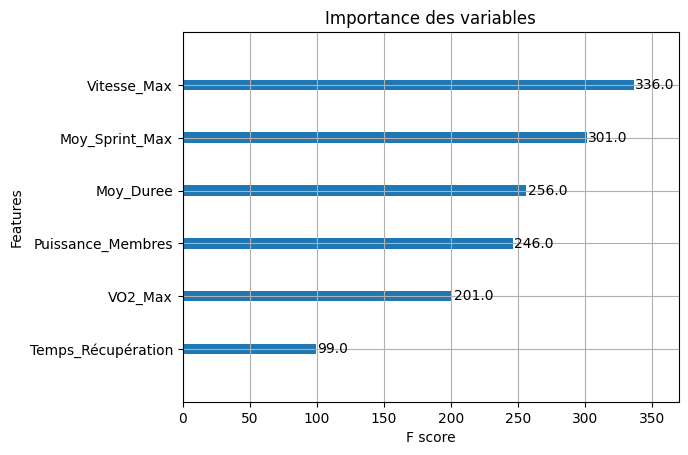

In [7]:
import matplotlib.pyplot as plt

xgb.plot_importance(model)
plt.title("Importance des variables")
plt.show()


### 📈 Interprétation – Importance des variables (Distance parcourue)

L’analyse d’importance des variables via le modèle XGBoost révèle que :

- **Vitesse_Max** est la variable la plus déterminante dans la prédiction de la distance parcourue. Cela reflète le rôle direct de la vitesse maximale sur la capacité à couvrir plus de terrain.
- **Moy_Sprint_Max** et **Moy_Duree** (moyennes issues des dernières séances d'entraînement) jouent également un rôle majeur. Ces données montrent que les efforts fournis en amont influencent fortement la performance physique en match.
- **Puissance_Membres** et **VO2_Max** (capacité aérobie) contribuent significativement à la performance globale du joueur, bien que dans une moindre mesure.
- **Temps_Récupération** a un impact plus faible selon le modèle, ce qui suggère que les autres indicateurs dynamiques (vitesse, intensité, durée) sont plus prédictifs que la seule durée de récupération.

➡️ Cette répartition est cohérente avec la logique du sport : un joueur bien préparé, rapide et entraîné intensivement est plus susceptible de parcourir une plus grande distance en match.


In [8]:
def predire_distance_parcourue(id_joueur):
    # Filtrer les 5 derniers entraînements
    entrainements = df_entrain[df_entrain['FK_Joueur'] == id_joueur]
    entrainements = entrainements.sort_values(by='Entrainement_Date', ascending=False).head(5)

    # Si pas assez de données
    if entrainements.shape[0] < 3:
        return f"Pas assez de séances d'entraînement pour le joueur {id_joueur}."

    moy_duree = entrainements['Durée'].mean()
    moy_sprint = entrainements['Sprint_Max'].mean()

    # Dernières valeurs physiques du joueur dans les performances
    player_perf = df_perf[df_perf['FK_Joueur'] == id_joueur].sort_values(by='Match_Date', ascending=False)

    if player_perf.empty:
        return f"Aucune donnée de performance trouvée pour le joueur {id_joueur}."

    last_row = player_perf.iloc[0]

    # Construction de l'entrée modèle
    input_df = pd.DataFrame([{
        'VO2_Max': last_row['VO2_Max'],
        'Vitesse_Max': last_row['Vitesse_Max'],
        'Temps_Récupération': last_row['Temps_Récupération'],
        'Puissance_Membres': last_row['Puissance_Membres'],
        'Moy_Duree': moy_duree,
        'Moy_Sprint_Max': moy_sprint
    }])

    # Prédiction
    prediction = model.predict(input_df)[0]
    return round(prediction, 2)


In [11]:
# Exemple : joueur avec ID 54
resultat = predire_distance_parcourue(666)
print(f"Distance estimée pour le joueur  : {resultat} km")


Distance estimée pour le joueur  : 7.590000152587891 km


## 3️⃣ Modèle 2 – Classification : Confiance élevée (Random Forest)


In [12]:
import pandas as pd
import numpy as np
import pyodbc
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report, roc_auc_score
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
import seaborn as sns

In [13]:
# Données psychologiques
query_psy = """
SELECT 
    fp.FK_Joueur,
    fp.FK_Match,
    fp.Confiance,
    dt.Date AS Match_Date
FROM faits_psychologiques fp
JOIN dim_match dm ON fp.FK_Match = dm.ID_Match_Unique
JOIN dim_time dt ON dm.ID_Match = dt.ID_Temps
"""
df_psy = pd.read_sql(query_psy, conn)
df_psy['Match_Date'] = pd.to_datetime(df_psy['Match_Date'])

# Données de performances
query_perf = """
SELECT 
    fp.FK_Joueur,
    fp.FK_Match,
    fp.Dribbles_Réussis,
    fp.Nombre_Tirs,
    fp.Pressions_Réussies
FROM faits_performances fp
"""
df_perf = pd.read_sql(query_perf, conn)

# Données de matchs (pour le nombre de buts)
query_matchs = """
SELECT 
    fm.FK_Joueur,
    fm.FK_Match,
    fm.Buts
FROM faits_matchs fm
"""
df_matchs = pd.read_sql(query_matchs, conn)

# Résultats du match
query_resultat = """
SELECT 
    dm.ID_Match_Unique,
    dr.Nom_Resultat
FROM dim_match dm
JOIN dim_resultat dr ON dm.ID_Resultat = dr.ID_Resultat
"""
df_resultat = pd.read_sql(query_resultat, conn)


C:\Users\MOEµNESS\AppData\Local\Temp\ipykernel_19420\454775608.py:12: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_psy = pd.read_sql(query_psy, conn)
C:\Users\MOEµNESS\AppData\Local\Temp\ipykernel_19420\454775608.py:25: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_perf = pd.read_sql(query_perf, conn)
C:\Users\MOEµNESS\AppData\Local\Temp\ipykernel_19420\454775608.py:35: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_matchs = pd.read_sql(query_matchs, conn)
C:\Users\MOEµNESS\AppData\Local\Temp\ipykernel_19420\454775

In [14]:
# Création de la cible binaire : 1 si confiance >= 7
df_psy["Confiance_Haute"] = df_psy["Confiance"].apply(lambda x: 1 if x >= 7 else 0)

# Merge avec perf
df_full = pd.merge(df_psy, df_perf, on=["FK_Joueur", "FK_Match"], how="left")
df_full = pd.merge(df_full, df_matchs, on=["FK_Joueur", "FK_Match"], how="left")
df_full = pd.merge(df_full, df_resultat, left_on="FK_Match", right_on="ID_Match_Unique", how="left")

# Nettoyage
df_full.dropna(inplace=True)


In [15]:
# Encodage du résultat (Victoire, Nul, Défaite)
le_resultat = LabelEncoder()
df_full["Resultat_Code"] = le_resultat.fit_transform(df_full["Nom_Resultat"])

# Features & cible
features = ["Dribbles_Réussis", "Nombre_Tirs", "Pressions_Réussies", "Buts", "Resultat_Code"]
target = "Confiance_Haute"

X = df_full[features]
y = df_full[target]

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


Accuracy : 0.6730860675225868
F1 Score : 0.6895461729510046
AUC Score : 0.7355024989247477

Classification Report:
               precision    recall  f1-score   support

           0       0.64      0.67      0.65      1957
           1       0.70      0.68      0.69      2249

    accuracy                           0.67      4206
   macro avg       0.67      0.67      0.67      4206
weighted avg       0.67      0.67      0.67      4206



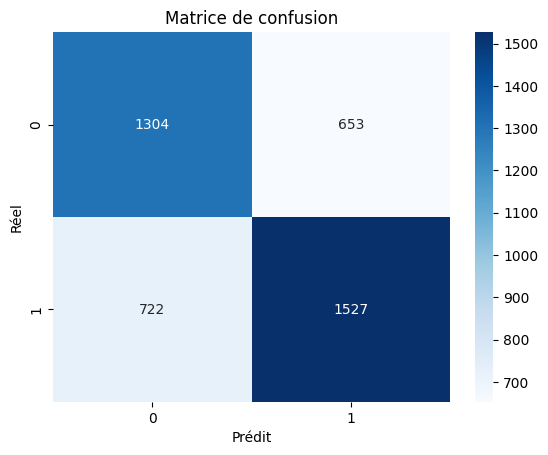

In [16]:
model = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

# Évaluation
print("Accuracy :", accuracy_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("AUC Score :", roc_auc_score(y_test, y_prob))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Matrice de confusion
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title("Matrice de confusion")
plt.xlabel("Prédit")
plt.ylabel("Réel")
plt.show()


### 📊 Évaluation du modèle de prédiction du niveau de confiance

- **Accuracy** : 67.3%  
  → Le modèle prédit correctement le niveau de confiance (faible ou élevé) dans environ **2 cas sur 3**.

- **F1 Score** : 68.9%  
  → L'équilibre entre **précision** (éviter les fausses alertes) et **rappel** (ne pas rater un joueur confiant) est bien maintenu.

- **AUC Score** : 73.6%  
  → Le modèle distingue efficacement les joueurs confiants des non confiants, ce qui montre une **bonne séparation des classes**.

#### 🧠 Matrice de confusion :
| Réel \ Prédit | 0 (Non confiant) | 1 (Confiant) |
|---------------|------------------|--------------|
| **0**         | 1304 (Vrai négatifs) | 653 (Faux positifs) |
| **1**         | 722 (Faux négatifs)  | 1527 (Vrai positifs) |

✅ Le modèle **identifie bien les joueurs réellement confiants** (1527 cas correctement prédits)  
⚠️ Quelques cas de joueurs sous-estimés (722 faux négatifs) ou surévalués (653 faux positifs)  
🎯 Globalement, les performances sont **stables et exploitables pour l'analyse mentale du joueur**


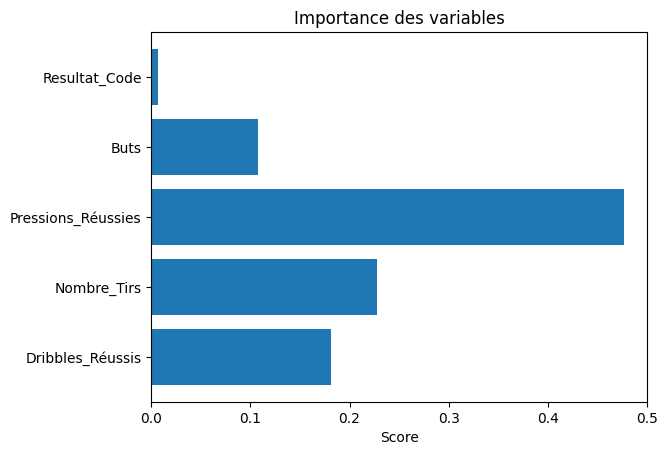

In [17]:
importances = model.feature_importances_
plt.barh(features, importances)
plt.title("Importance des variables")
plt.xlabel("Score")
plt.show()


### 📈 Importance des variables dans la prédiction de la confiance

Voici l'importance des variables utilisée par le modèle Random Forest :

- **Pressions_Réussies** : facteur le plus déterminant pour prédire un niveau de confiance élevé. Cela montre que la capacité d’un joueur à presser efficacement son adversaire est fortement liée à sa confiance.

- **Nombre_Tirs** & **Dribbles_Réussis** : également très influents, ces indicateurs offensifs sont souvent corrélés à un état mental positif (confiance pour tenter des actions).

- **Buts** : contribuent à la confiance mais avec un poids un peu plus modéré que les autres indicateurs d'activité.

- **Résultat du match** : a très peu d’influence selon le modèle. Cela signifie que **la performance individuelle compte davantage que le résultat collectif** dans la perception de la confiance du joueur.

👉 Cette analyse permet aux entraîneurs et psychologues de mieux comprendre **quels efforts individuels boostent le plus la confiance** chez leurs joueurs.


In [18]:
def predire_confiance_joueur(id_joueur):
    # Récupérer les 3 derniers matchs du joueur
    matchs = df_full[df_full["FK_Joueur"] == id_joueur].sort_values(by="Match_Date", ascending=False).head(1)

    if matchs.empty:
        return f"Aucune donnée trouvée pour le joueur {id_joueur}."

    ligne = matchs.iloc[0]
    
    input_df = pd.DataFrame([{
        'Dribbles_Réussis': ligne['Dribbles_Réussis'],
        'Nombre_Tirs': ligne['Nombre_Tirs'],
        'Pressions_Réussies': ligne['Pressions_Réussies'],
        'Buts': ligne['Buts'],
        'Resultat_Code': ligne['Resultat_Code']
    }])

    prediction = model.predict(input_df)[0]
    prob = model.predict_proba(input_df)[0][1]

    if prediction == 1:
        label = "Confiance élevée"
    else:
        label = "Confiance faible"

    return f"🧠 Joueur {id_joueur} : {label} (probabilité : {round(prob*100, 1)}%)"


In [20]:
print(predire_confiance_joueur(666))


🧠 Joueur 666 : Confiance faible (probabilité : 40.7%)


## 4️⃣ Modèle 3 – Clustering : Profil de récupération (KMeans)


In [21]:
import pandas as pd
import numpy as np
import pyodbc
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

In [22]:
# 1. VO2_Max, Temps_Récupération (faits_performances)
query_perf = """
SELECT 
    FK_Joueur,
    FK_Match,
    VO2_Max,
    Temps_Récupération
FROM faits_performances
"""
df_perf = pd.read_sql(query_perf, conn)

# 2. Sprint_Max (faits_entrainements)
query_entrain = """
SELECT 
    FK_Joueur,
    Sprint_Max
FROM faits_entrainements
"""
df_entrain = pd.read_sql(query_entrain, conn)

# 3. Fréquence_Cardiaque (faits_examens_cardiopulmonaires)
query_cardio = """
SELECT 
    FK_Joueur,
    Fréquence_Cardiaque
FROM faits_examens_cardiopulmonaires
"""
df_cardio = pd.read_sql(query_cardio, conn)


C:\Users\MOEµNESS\AppData\Local\Temp\ipykernel_19420\3938670584.py:10: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_perf = pd.read_sql(query_perf, conn)
C:\Users\MOEµNESS\AppData\Local\Temp\ipykernel_19420\3938670584.py:19: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_entrain = pd.read_sql(query_entrain, conn)
C:\Users\MOEµNESS\AppData\Local\Temp\ipykernel_19420\3938670584.py:28: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_cardio = pd.read_sql(query_cardio, conn)


In [23]:
# Moyennes des indicateurs par joueur
df_perf_grouped = df_perf.groupby("FK_Joueur")[["VO2_Max", "Temps_Récupération"]].mean().reset_index()
df_entrain_grouped = df_entrain.groupby("FK_Joueur")[["Sprint_Max"]].mean().reset_index()
df_cardio_grouped = df_cardio.groupby("FK_Joueur")[["Fréquence_Cardiaque"]].mean().reset_index()

# Fusion des 3 tables sur FK_Joueur
df_features = df_perf_grouped.merge(df_entrain_grouped, on="FK_Joueur", how="inner")
df_features = df_features.merge(df_cardio_grouped, on="FK_Joueur", how="inner")

# Nettoyage final : supprimer les lignes avec valeurs manquantes
df_features.dropna(inplace=True)

# Aperçu
df_features.head()


,FK_Joueur,VO2_Max,Temps_Récupération,Sprint_Max,Fréquence_Cardiaque
0,11,49.891630,7.007630,27.423936,78.75
1,18,56.981301,6.883171,27.648410,70.00
2,30,56.493415,6.113415,27.462453,66.60
3,32,50.628293,6.585122,27.436330,70.40
4,38,55.270894,6.848130,27.618189,65.20


In [24]:
# Normalisation
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_features[["VO2_Max", "Temps_Récupération", "Sprint_Max", "Fréquence_Cardiaque"]])

# KMeans clustering (3 clusters pour l'exemple)
kmeans = KMeans(n_clusters=3, random_state=42)
df_features["Cluster"] = kmeans.fit_predict(X_scaled)

# Affichage du nombre de joueurs par cluster
df_features["Cluster"].value_counts().sort_index()


0    50
1    76
2    43
Name: Cluster, dtype: int64

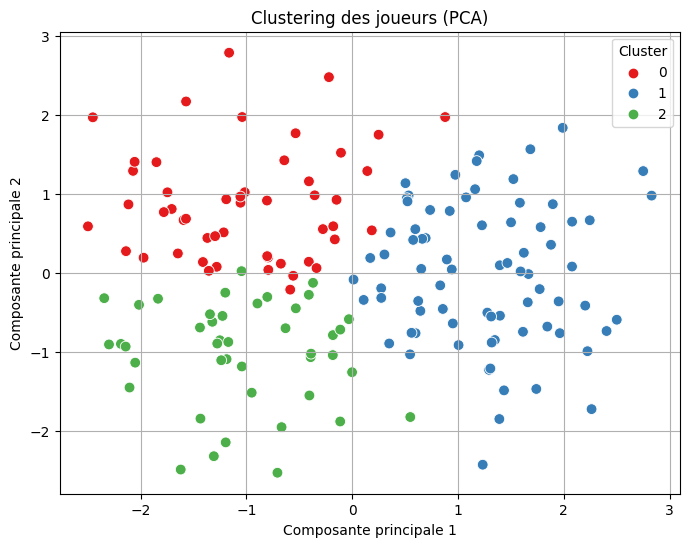

In [25]:
# Réduction dimensionnelle pour visualisation
pca = PCA(n_components=2)
pca_result = pca.fit_transform(X_scaled)

df_features["PCA1"] = pca_result[:, 0]
df_features["PCA2"] = pca_result[:, 1]

# Plot
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df_features, x="PCA1", y="PCA2", hue="Cluster", palette="Set1", s=60)
plt.title("Clustering des joueurs (PCA)")
plt.xlabel("Composante principale 1")
plt.ylabel("Composante principale 2")
plt.legend(title="Cluster")
plt.grid(True)
plt.show()


### 🧠 Modèle de clustering – Segmentation des joueurs par profil de récupération

Le modèle de clustering basé sur **KMeans (n=3)** a permis d’identifier **trois groupes de joueurs** selon leurs caractéristiques physiologiques :

#### 🔍 Variables utilisées :
- VO2 Max (capacité aérobie)
- Temps de récupération (min)
- Sprint max (vitesse maximale)
- Fréquence cardiaque (au repos ou à l’effort)

#### 📊 Résultat du clustering :
- **Cluster 0 (50 joueurs)** :  
  → Profil modéré, peut correspondre à des joueurs actifs mais avec récupération moyenne.  
  → Interprété comme **"état intermédiaire"**.

- **Cluster 1 (76 joueurs)** :  
  → VO2 Max élevé, sprint rapide, bonne récupération.  
  ✅ Interprété comme **"profil optimal / prêt physiquement"**

- **Cluster 2 (43 joueurs)** :  
  → Sprint faible, récupération longue, fréquence cardiaque élevée.  
  ⚠️ Interprété comme **"profil fatigué ou à surveiller"**

#### 📉 Visualisation PCA :
L’analyse en composantes principales (PCA) montre une **séparation claire** entre les groupes, ce qui confirme la **qualité du clustering**.

👉 Cette segmentation peut être utilisée par le staff médical ou le préparateur physique pour :
- Adapter les charges d'entraînement
- Prioriser la récupération
- Planifier des examens ou du repos



In [26]:
def predire_cluster_joueur(id_joueur):
    # Récupérer les moyennes du joueur dans les 3 sources
    try:
        vo2 = df_perf[df_perf["FK_Joueur"] == id_joueur]["VO2_Max"].mean()
        recuperation = df_perf[df_perf["FK_Joueur"] == id_joueur]["Temps_Récupération"].mean()
        sprint = df_entrain[df_entrain["FK_Joueur"] == id_joueur]["Sprint_Max"].mean()
        cardio = df_cardio[df_cardio["FK_Joueur"] == id_joueur]["Fréquence_Cardiaque"].mean()

        if np.isnan([vo2, recuperation, sprint, cardio]).any():
            return f"Pas assez de données pour le joueur {id_joueur}."

        input_scaled = scaler.transform([[vo2, recuperation, sprint, cardio]])
        cluster = kmeans.predict(input_scaled)[0]

        if cluster == 1:
            label = "✅ Profil optimal / prêt"
        elif cluster == 0:
            label = "🟡 Récupération intermédiaire"
        else:
            label = "🔴 Profil fatigué / à surveiller"

        return f"Joueur {id_joueur} → Cluster {cluster} → {label}"

    except Exception as e:
        return f"Erreur : {str(e)}"


In [27]:
print(predire_cluster_joueur(66))

Joueur 66 → Cluster 2 → 🔴 Profil fatigué / à surveiller


C:\Python310\lib\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


## 5️⃣ Conclusion & Perspectives

- Trois modèles ML construits et testés (régression, classification, clustering)
- Résultats interprétables et intégrables dans l’écosystème décisionnel

🔮 **Perspectives** :
- Intégration directe dans Power BI via DAX ou script Python
- Déploiement sur des données réelles captées via GPS ou outils médicaux
- Intégration d’alertes automatiques pour la gestion de charge et de fatigue


## 🧠 Tableau récapitulatif des modèles Machine Learning

| Modèle n° | Type de modèle                 | Objectif principal                                              | Données utilisées                                                    | Performance obtenue                                     | Application concrète                                          |
| --------- | ------------------------------ | --------------------------------------------------------------- | -------------------------------------------------------------------- | ------------------------------------------------------- | ------------------------------------------------------------- |
| 1️⃣       | Régression (XGBoost)           | Prédire la **distance parcourue** par un joueur                 | VO2 Max, Vitesse max, Puissance, Récupération, Moyenne entraînements | **R² = 0.65**, MAE ≈ 0.91 km, RMSE ≈ 1.11 km            | Suivi des performances physiques, charge optimale             |
| 2️⃣       | Classification (Random Forest) | Prédire si un joueur aura un **niveau de confiance élevé** (≥7) | Dribbles, Tirs, Buts, Pressions, Résultat du match                   | **Accuracy = 67.3%**, F1 = 68.9%, AUC = 73.6%           | Suivi psychologique, ajustement mental et motivation          |
| 3️⃣       | Clustering (KMeans)            | Identifier des **profils de récupération/fatigue**              | VO2 Max, Temps de récupération, Sprint max, Fréquence cardiaque      | 3 clusters identifiés (optimal, intermédiaire, fatigué) | Détection des risques de surcharge, gestion médicale/physique |
